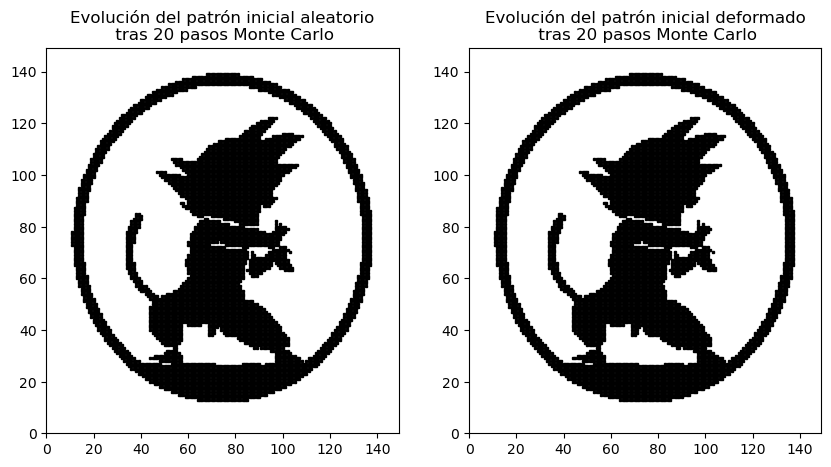

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargo las configuraciones de las neuronas desde el archivo generado
Matriz_neuronas_inicial_aleatoria = np.loadtxt('Configuracion_inicial_neuronas_aleatoria.txt')
Matriz_neuronas_inicial_deformada = np.loadtxt('Configuracion_inicial_neuronas_deformada.txt')

# Modifico la forma de la matriz para que sea un array de M matrices 150x150
Matriz_neuronas_inicial_aleatoria = Matriz_neuronas_inicial_aleatoria.reshape(-1, 150, 150)
Matriz_neuronas_inicial_deformada = Matriz_neuronas_inicial_deformada.reshape(-1, 150, 150)

M = Matriz_neuronas_inicial_aleatoria.shape[0]
    
# Creo la figura para la animación
fig, ax = plt.subplots(1,2,figsize = (10, 5))
ax[0].set_title('Evolución del patrón inicial aleatorio\n tras 20 pasos Monte Carlo')
ax[0].set_xlim(0, 149)
ax[0].set_ylim(0, 149)
ax[1].set_title('Evolución del patrón inicial deformado\n tras 20 pasos Monte Carlo')
ax[1].set_xlim(0, 149)
ax[1].set_ylim(0, 149)

# Configuro la línea para la animación, donde los 1 se representan en color negro y los 0 se dejan en blanco
line_1, = ax[0].plot([], [], color = 'black', marker = 's', linestyle = 'None', markersize = 1.5)
line_2, = ax[1].plot([], [], color = 'black', marker = 's', linestyle = 'None', markersize = 1.5)

# Función para realizar la animación
def animate(i):
    
    pos_1 = np.where(Matriz_neuronas_inicial_aleatoria[i, :, :] == 1)
    pos_2 = np.where(Matriz_neuronas_inicial_deformada[i, :, :] == 1)

    line_1.set_data(pos_1[1], 149 - pos_1[0])
    line_2.set_data(pos_2[1], 149 - pos_2[0])

    return line_1, line_2

# Creo una animación usando la función animate
ani = animation.FuncAnimation(fig, animate, frames = M, interval = 100, blit = True)

# Guardo la animación como un archivo GIF
ani.save("Configuracion_neuronas_animacion.gif", writer='pillow', dpi = 150)